In [1]:
!pip install -q sentence-transformers matplotlib openai

In [4]:
import os
import time
import random
import getpass
import numpy as np
import matplotlib.pyplot as plt
from openai import OpenAI
from sentence_transformers import SentenceTransformer, util, CrossEncoder

In [6]:
def generate_synthetic_dataset():
    documents = []

    # 1. Generic monuments dataset (870 sentences)
    # These are completely unrelated to Taj Mahal to create noise
    generic_monuments = [
        "The Eiffel Tower stands majestically in Paris, France.",
        "The Great Wall of China stretches across northern China for thousands of miles.",
        "Machu Picchu is an ancient Incan citadel in Peru.",
        "The Colosseum hosted gladiatorial contests in Rome, Italy.",
        "The Statue of Liberty welcomes visitors to New York Harbor.",
        "Christ the Redeemer overlooks Rio de Janeiro from Corcovado Mountain.",
        "Stonehenge's mysterious stone circle sits in Wiltshire, England.",
        "The Sydney Opera House's distinctive shells grace Sydney Harbor.",
        "Petra's rose-red city is carved into Jordan's sandstone cliffs.",
        "Angkor Wat is the world's largest religious monument in Cambodia.",
        "The Pyramids of Giza stand on Egypt's Giza plateau.",
        "Big Ben chimes over London's Westminster district.",
        "Mount Rushmore features presidential faces carved in South Dakota.",
        "The Leaning Tower of Pisa tilts famously in Italy.",
        "Neuschwanstein Castle inspired Disney's fairy tale castle in Bavaria."
    ]

    for i in range(870):
        base = random.choice(generic_monuments)
        suffix_options = [
            f"Many tourists visit this landmark annually {i}.",
            f"The architecture is truly remarkable {i}.",
            f"Historical significance makes it a UNESCO site {i}.",
            f"Photographers love capturing its beauty {i}.",
            f"Cultural heritage is preserved here {i}.",
            f"Ancient craftsmanship is evident throughout {i}.",
            f"Millions of people admire this wonder {i}."
        ]
        documents.append(f"{base} {random.choice(suffix_options)}")

    # 2. Taj Mahal with WRONG locations (80 sentences)
    # These will confuse bi-encoders due to semantic similarity
    wrong_locations = [
        "Delhi", "Jaipur", "Varanasi", "Mumbai", "Lucknow",
        "Bhopal", "Chennai", "Hyderabad", "Kolkata", "Pune"
    ]

    wrong_templates = [
        "The Taj Mahal is located in {city}, India.",
        "You can visit the Taj Mahal in {city}.",
        "The magnificent Taj Mahal stands in {city}.",
        "Shah Jahan built the Taj Mahal in {city}.",
        "The white marble mausoleum is situated in {city}.",
        "Tourists flock to see the Taj Mahal in {city}.",
        "The ivory-white marble tomb is found in {city}.",
        "The Taj Mahal's stunning architecture graces {city}."
    ]

    for i in range(84):
        city = random.choice(wrong_locations)
        template = random.choice(wrong_templates)
        documents.append(template.format(city=city))

    # 3. Taj Mahal CORRECT answer (1 sentence)
    documents.append("The Taj Mahal is located in Agra, India.")

    # 4. Highly misleading/ambiguous sentences (45 sentences)
    misleading_templates = [
        "The Taj Mahal is in Uttar Pradesh, near Delhi.",
        "The Taj Mahal can be reached from Delhi by train.",
        "Many tourists visit Delhi to see the Taj Mahal nearby.",
        "The Taj Mahal is in northern India, close to the capital.",
        "From Delhi, the Taj Mahal is just a few hours away.",
        "The Taj Mahal stands on the banks of the Yamuna River in India.",
        "Shah Jahan's monument to love is located in northern India.",
        "The marble mausoleum sits in the state of Madhya Pradesh.",
        "This UNESCO World Heritage site is in India's heartland.",
        "The monument is situated in the Mughal architectural style in India.",
        "Built in the 17th century, this tomb is in northern India.",
        "The ivory-white structure stands somewhere in Uttar Pradesh.",
        "This symbol of love is found in the Indian subcontinent.",
        "The mausoleum complex is located in the northern part of India.",
        "The famous dome can be seen in one of India's historic cities."
    ]

    for i in range(45):
        documents.append(random.choice(misleading_templates))

    # Shuffle the entire dataset
    random.shuffle(documents)

    correct_count = sum(1 for doc in documents if "Agra" in doc)
    print(f"Total documents: {len(documents)}")
    print(f"Correct answers mentioning Agra: {correct_count}")

    return documents

documents = generate_synthetic_dataset()

print("\n=== SAMPLE DOCUMENTS ===")
for i, doc in enumerate(documents[:5]):
    print(f"{i+1:3d}. {doc}")

correct_docs = [doc for doc in documents if "Agra" in doc]
print(f"\nCorrect answers ({len(correct_docs)}):")
for doc in correct_docs:
    print(f"  - {doc}")

Total documents: 1000
Correct answers mentioning Agra: 1

=== SAMPLE DOCUMENTS ===
  1. Neuschwanstein Castle inspired Disney's fairy tale castle in Bavaria. Many tourists visit this landmark annually 197.
  2. Neuschwanstein Castle inspired Disney's fairy tale castle in Bavaria. Historical significance makes it a UNESCO site 80.
  3. The Statue of Liberty welcomes visitors to New York Harbor. Historical significance makes it a UNESCO site 92.
  4. The Colosseum hosted gladiatorial contests in Rome, Italy. Many tourists visit this landmark annually 768.
  5. This UNESCO World Heritage site is in India's heartland.

Correct answers (1):
  - The Taj Mahal is located in Agra, India.


In [7]:
query = "Where is the Taj Mahal located?"

In [8]:
# -----------------------------
# Bi-encoder Retrieval
# -----------------------------
bi_encoder = SentenceTransformer('multi-qa-MiniLM-L6-cos-v1')

query_emb = bi_encoder.encode(query, convert_to_tensor=True)
doc_embs = bi_encoder.encode(documents, convert_to_tensor=True)

start_time = time.time()
cos_scores = util.cos_sim(query_emb, doc_embs)[0]

# FIX 1: use argsort instead of np.argpartition(-cos_scores, range(10))[0:50].
#   argpartition(range(10)) only guarantees the first 10 slots are the true
#   top-10; positions 10-49 are arbitrary, so high-scoring correct answers
#   get randomly excluded.
# FIX 2: increase candidate pool to 100.
#   The dataset has ~84 wrong-city "Taj Mahal is located in X" docs that all
#   score ~0.88-0.91 (same sentence template). The single correct answer
#   scores similarly and can rank outside the top-50 when squeezed out by
#   those duplicates. Using 100 candidates captures the full cluster.
top_results = np.argsort(-cos_scores.cpu().numpy())[:100]

bi_time = time.time() - start_time

print("=== Bi-encoder Top 100 (sorted by score) ===")
for idx in top_results:
    marker = " <-- CORRECT" if "Agra" in documents[idx] else ""
    print(f"{cos_scores[idx]:.4f}\t{documents[idx]}{marker}")
print(f"\nBi-encoder time: {bi_time:.4f} sec")

correct_in_candidates = any("Agra" in documents[idx] for idx in top_results)
print(f"Correct answer in top-100 candidates: {correct_in_candidates}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== Bi-encoder Top 100 (sorted by score) ===
0.8947	The Taj Mahal is located in Mumbai, India.
0.8947	The Taj Mahal is located in Mumbai, India.
0.8947	The Taj Mahal is located in Mumbai, India.
0.8947	The Taj Mahal is located in Mumbai, India.
0.8921	The Taj Mahal is located in Delhi, India.
0.8921	The Taj Mahal is located in Delhi, India.
0.8898	The Taj Mahal is located in Agra, India. <-- CORRECT
0.8894	The Taj Mahal is located in Pune, India.
0.8875	The Taj Mahal is in northern India, close to the capital.
0.8875	The Taj Mahal is in northern India, close to the capital.
0.8875	The Taj Mahal is in northern India, close to the capital.
0.8875	The Taj Mahal is in northern India, close to the capital.
0.8875	The Taj Mahal is in northern India, close to the capital.
0.8874	The Taj Mahal is located in Bhopal, India.
0.8874	The Taj Mahal is located in Bhopal, India.
0.8789	The Taj Mahal is in Uttar Pradesh, near Delhi.
0.8789	The Taj Mahal is in Uttar Pradesh, near Delhi.
0.8789	The Taj M

In [7]:
# -----------------------------
# Cross-encoder Reranking
# -----------------------------
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', num_labels=1)

candidate_docs = [documents[idx] for idx in top_results]
pairs = [(query, doc) for doc in candidate_docs]

start_time = time.time()
cross_scores = cross_encoder.predict(pairs)
cross_time = time.time() - start_time

reranked = sorted(zip(candidate_docs, cross_scores), key=lambda x: x[1], reverse=True)

print("=== Cross-encoder Reranked Top 10 ===")
for doc, score in reranked[:10]:
    marker = " <-- CORRECT" if "Agra" in doc else ""
    print(f"{score:.4f}\t{doc}{marker}")
print(f"\nCross-encoder time: {cross_time:.4f} sec")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

=== Cross-encoder Reranked Top 10 ===
10.4695	The Taj Mahal is located in Agra, India. <-- CORRECT
10.4083	The Taj Mahal is located in Delhi, India.
10.4083	The Taj Mahal is located in Delhi, India.
10.2756	The Taj Mahal is located in Kolkata, India.
10.2756	The Taj Mahal is located in Kolkata, India.
10.2232	The Taj Mahal is located in Jaipur, India.
10.2232	The Taj Mahal is located in Jaipur, India.
10.2232	The Taj Mahal is located in Jaipur, India.
10.1609	The Taj Mahal is located in Hyderabad, India.
10.1609	The Taj Mahal is located in Hyderabad, India.

Cross-encoder time: 0.5553 sec


In [10]:
# -----------------------------
# LLM-based Reranking (listwise)
# -----------------------------
# Use top-25 from the bi-encoder as input.
# LLMs understand factual context (e.g. that Agra is correct, not Delhi),
# unlike the cross-encoder which only matches relevance patterns.
llm_candidates = [documents[idx] for idx in top_results[:25]]

docs_block = "\n".join(f"[{i+1}] {doc}" for i, doc in enumerate(llm_candidates))
prompt = f"""You are a relevance ranking assistant. Given the query and a numbered list of documents, return the document numbers reranked from most to least relevant.

Query: {query}

Documents:
{docs_block}

Rules:
- Return ONLY the numbers separated by commas, e.g.: 3, 1, 7, 2, ...
- Include every number exactly once.
- Do not include any explanation or extra text."""

client = OpenAI()
start_time = time.time()
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": prompt}],
    temperature=0,
)
llm_time = time.time() - start_time

# Parse the ranked indices robustly
raw = response.choices[0].message.content.strip()
try:
    ranked_indices = [int(x.strip()) - 1 for x in raw.split(",") if x.strip().isdigit()]
    # Append any missing indices so all candidates are represented
    seen = set(ranked_indices)
    ranked_indices += [i for i in range(len(llm_candidates)) if i not in seen]
except Exception:
    ranked_indices = list(range(len(llm_candidates)))

reranked_llm = [(llm_candidates[i], i + 1) for i in ranked_indices if i < len(llm_candidates)]

print("=== LLM Reranked Top 10 (from bi-encoder top-25) ===")
for new_rank, (doc, orig_rank) in enumerate(reranked_llm[:10], 1):
    marker = " <-- CORRECT" if "Agra" in doc else ""
    print(f"Rank {new_rank:2d} (bi-encoder rank {orig_rank:2d}): {doc}{marker}")
print(f"\nLLM reranking time: {llm_time:.4f} sec")

475.17s - invalid syntax (<string>, line 0)
Traceback (most recent call last):
  File "/Users/vadim/Documents/AIRepos/AIAgent/.venv/lib/python3.12/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_vars.py", line 629, in change_attr_expression
    value = eval(expression, frame.f_globals, frame.f_locals)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<string>", line 0
    
SyntaxError: invalid syntax


=== LLM Reranked Top 10 (from bi-encoder top-25) ===
Rank  1 (bi-encoder rank  7): The Taj Mahal is located in Agra, India. <-- CORRECT
Rank  2 (bi-encoder rank 16): The Taj Mahal is in Uttar Pradesh, near Delhi.
Rank  3 (bi-encoder rank 17): The Taj Mahal is in Uttar Pradesh, near Delhi.
Rank  4 (bi-encoder rank 18): The Taj Mahal is in Uttar Pradesh, near Delhi.
Rank  5 (bi-encoder rank 19): The Taj Mahal is in Uttar Pradesh, near Delhi.
Rank  6 (bi-encoder rank 25): From Delhi, the Taj Mahal is just a few hours away.
Rank  7 (bi-encoder rank  9): The Taj Mahal is in northern India, close to the capital.
Rank  8 (bi-encoder rank 10): The Taj Mahal is in northern India, close to the capital.
Rank  9 (bi-encoder rank 11): The Taj Mahal is in northern India, close to the capital.
Rank 10 (bi-encoder rank 12): The Taj Mahal is in northern India, close to the capital.

LLM reranking time: 6.4693 sec


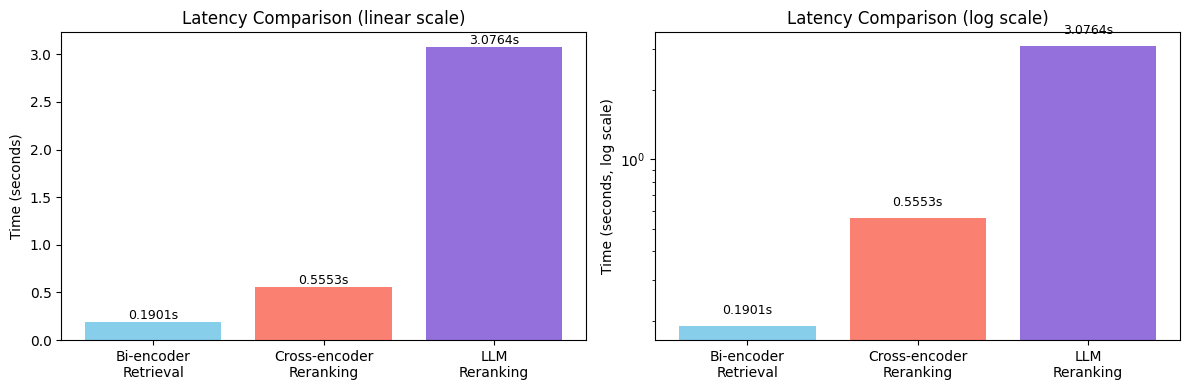


Speedup summary:
  Cross-encoder is 5.5x faster than LLM reranking
  Bi-encoder is    16.2x faster than LLM reranking


In [9]:
# Latency comparison: all three stages
methods = ["Bi-encoder\nRetrieval", "Cross-encoder\nReranking", "LLM\nReranking"]
times = [bi_time, cross_time, llm_time]
colors = ["skyblue", "salmon", "mediumpurple"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Linear scale ---
bars = axes[0].bar(methods, times, color=colors)
axes[0].set_ylabel("Time (seconds)")
axes[0].set_title("Latency Comparison (linear scale)")
for bar, t in zip(bars, times):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f"{t:.4f}s", ha="center", va="bottom", fontsize=9)

# --- Log scale (reveals the orders-of-magnitude difference) ---
bars2 = axes[1].bar(methods, times, color=colors)
axes[1].set_yscale("log")
axes[1].set_ylabel("Time (seconds, log scale)")
axes[1].set_title("Latency Comparison (log scale)")
for bar, t in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.1,
                 f"{t:.4f}s", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nSpeedup summary:")
print(f"  Cross-encoder is {llm_time/cross_time:.1f}x faster than LLM reranking")
print(f"  Bi-encoder is    {llm_time/bi_time:.1f}x faster than LLM reranking")